In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from torch import nn

from nnscaling import aesthetics
from nnscaling.data import (
    DatasetConfig,
    create_data_loader,
    get_dataset_class,
)
from nnscaling.models import MLP
from nnscaling.utils import (
    compute_model_accuracy,
    get_device,
    safetensors_metadata_parser,
)
from nnscaling.visualization import plot_decision_boundary

%load_ext autoreload
%autoreload 2

In [ ]:
file_path = "/home/nsa325/work/nnscaling/model_saves/mnist_model.safetensors"
model = MLP.load_model(file_path, in_features=2).eval()
model.summary()

Layer (type (var_name))                       Param #
MLP (MLP)                                     --
+ Sequential (_features)                      --
|    + LinearLayer (0)                        --
|    |    + Linear (linear)                   30
|    |    + BatchNorm1d (batchnorm_layer)     20
|    |    + ReLU (activation_layer)           --
|    + LinearLayer (1)                        --
|    |    + Linear (linear)                   88
|    |    + BatchNorm1d (batchnorm_layer)     16
|    |    + ReLU (activation_layer)           --
|    + LinearLayer (2)                        --
|    |    + Linear (linear)                   54
|    |    + BatchNorm1d (batchnorm_layer)     12
|    |    + ReLU (activation_layer)           --
|    + LinearLayer (3)                        --
|    |    + Linear (linear)                   21
|    |    + BatchNorm1d (batchnorm_layer)     6
|    |    + ReLU (activation_layer)           --
|    + LinearLayer (4)                        --
|    |    + Line

In [ ]:
# Dataset config
metadata = safetensors_metadata_parser(file_path=file_path)
dataset_config = DatasetConfig(
    dataset_name=metadata["dataset"],
    num_samples=3_000,
    split="test",
    seed=42,
)
DatasetClass = get_dataset_class(name=dataset_config.dataset_name)
dataset = DatasetClass(config=dataset_config)

In [ ]:
print(f"Testing Accuracy: {compute_model_accuracy(model, dataset)}")

Testing Accuracy: 0.9733333587646484


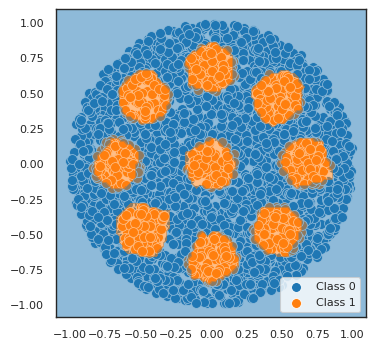

In [ ]:
if dataset.in_features == 2:
    plot_decision_boundary(
        model,
        model.state_dict(),
        dataset.features,
        dataset.labels.squeeze(),
        labels=[0, 1],
    )